In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\Wholesale customers data.csv")
print(df)

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  
..          ...

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
df.shape

(440, 8)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [10]:
df.dtypes

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

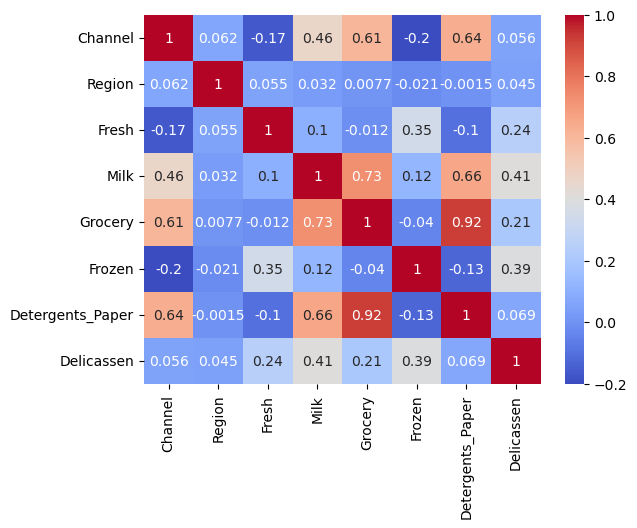

In [12]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

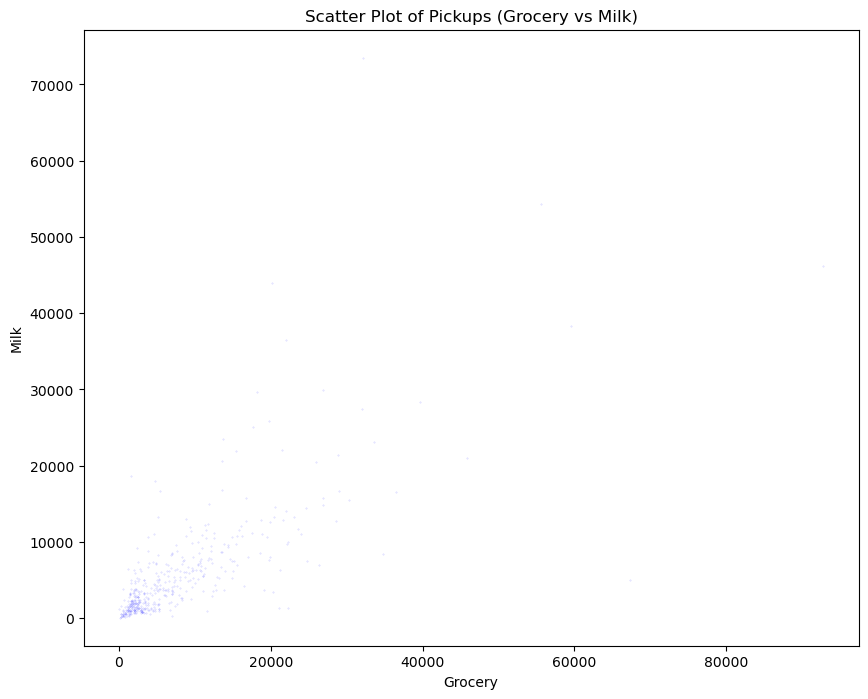

In [14]:
plt.figure(figsize=(10, 8))
plt.scatter(df["Grocery"], df["Milk"], s=0.1, alpha=0.2, color="blue")
plt.title("Scatter Plot of Pickups (Grocery vs Milk)")
plt.xlabel("Grocery")
plt.ylabel("Milk")
plt.show()

In [15]:
X=df.drop(["Channel","Region"],axis=1)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [17]:
from sklearn.cluster import KMeans

In [18]:
c=[]

In [19]:
for i in range(1,11):
    model=KMeans(n_clusters=i,random_state=42,n_init=10)
    model.fit(X_scaled)
    c.append(model.inertia_)

D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

In [20]:
c

[2640.0,
 1956.124277522268,
 1608.4311488289443,
 1317.8383605390707,
 1058.7712532570085,
 915.7412597498404,
 825.400252021833,
 737.386203336268,
 661.4495846389702,
 605.9151092090293]

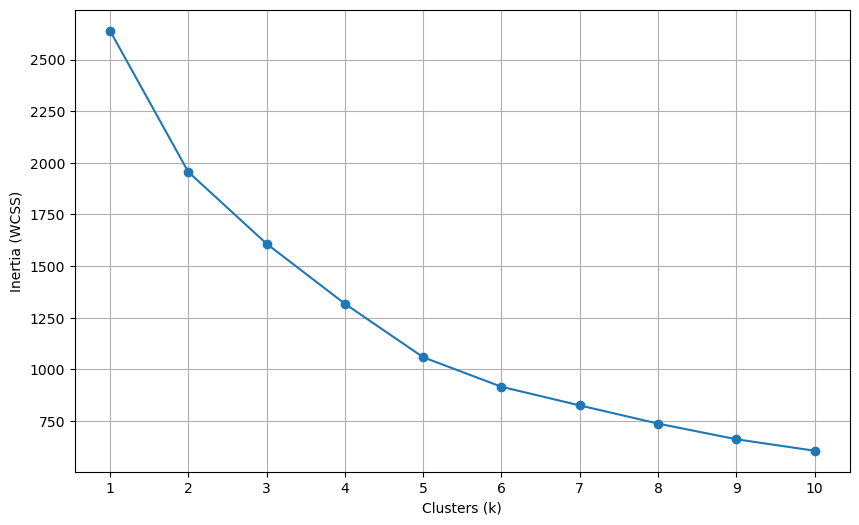

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), c, marker="o")
plt.xlabel("Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [22]:
model=KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10,
)

In [23]:
cluster=model.fit_predict(X_scaled)

D:\anaconda summer internship\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [24]:
df["cluster"]=cluster

In [25]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,3
2,2,3,6353,8808,7684,2405,3516,7844,3
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,2


In [26]:
df["cluster"].value_counts()

cluster
0    270
3     96
2     63
1     10
4      1
Name: count, dtype: int64

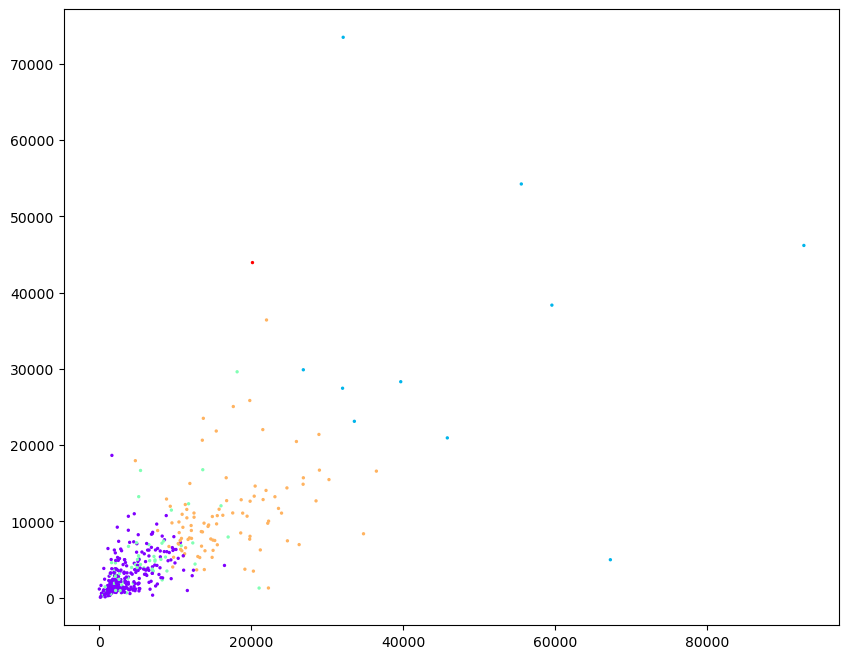

In [28]:
plt.figure(figsize=(10,8))
plt.scatter(
    df["Grocery"],
    df["Milk"],
    c = df["cluster"],
    cmap = "rainbow",
    s = 2
)
plt.show()

In [29]:
centeroids=scaler.inverse_transform(model.cluster_centers_)

In [30]:
centeroids

array([[ 9092.15555556,  2967.75925926,  3807.41111111,  2271.75925926,
          989.81481481,   978.96296296],
       [15964.9       , 34708.5       , 48536.9       ,  3054.6       ,
        24875.2       ,  2942.8       ],
       [32957.98412698,  4997.34920635,  5884.76190476,  8422.84126984,
          954.6031746 ,  2462.96825397],
       [ 5754.16666667, 10866.60416667, 16607.10416667,  1464.125     ,
         7202.875     ,  1813.38541667],
       [36847.        , 43950.        , 20170.        , 36534.        ,
          239.        , 47943.        ]])

In [31]:
Y=df["cluster"]

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

In [36]:
tree_model.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
y_pred = tree_model.predict(X_test)  

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy=accuracy_score(Y_test,y_pred)